# Portland Cement Data Beispiel

* Ein Ingenieur untersucht die Zusammensetzung eines Portlandzementmörtels.
* Während des Mischvorgangs wird eine Polymer-Latex-Emulsion zugesetzt.
* Es soll untersucht werden, ob dieser Zusatz die Zugverbundfestigkeit des Mörtels beeinflusst.
* Es liegen 10 Proben der ursprünglichen Formulierung und 10 Proben der modifizierten Formulierung vor.

## Portland Cement Datengrundlage

![title](../img/table2_1.png)

# Dateneingabe

Die Messwerte werden zunächst in einem DataFrame mit zwei Spalten gespeichert.

Jede Zeile enthält die Festigkeitsmessung einer Probe. Die beiden Formulierungen werden zunächst getrennt gespeichert, da dies die Berechnung der deskriptiven Statistiken und des Zweistichproben-t-Tests erleichtert.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Modified_Mortar": [
        16.85, 16.40, 17.21, 16.35, 16.52,
        17.04, 16.96, 17.15, 16.59, 16.57
    ],
    "Unmodified_Mortar": [
        16.62, 16.75, 17.37, 17.12, 16.98,
        16.87, 17.34, 17.02, 17.08, 17.27
    ]
})

#df.index.name = "Sample"

df

,Modified_Mortar,Unmodified_Mortar
0,16.85,16.62
1,16.40,16.75
2,17.21,17.37
3,16.35,17.12
4,16.52,16.98
5,17.04,16.87
6,16.96,17.34
7,17.15,17.02
8,16.59,17.08
9,16.57,17.27


Für viele Visualisierungen und statistische Verfahren ist ein sogenanntes Long-Format praktisch.

Dabei werden alle Festigkeitswerte in einer gemeinsamen Spalte gespeichert. Eine zweite Spalte enthält die Information, zu welcher Formulierung die jeweilige Beobachtung gehört.

Dieses Datenformat wird von vielen Python-Paketen wie Seaborn oder Statsmodels bevorzugt.

In [2]:
df_long = df.melt(
    value_vars=["Modified_Mortar", "Unmodified_Mortar"],
    var_name="Mortar_Type",
    value_name="Bond_Strength"
)

df_long

,Mortar_Type,Bond_Strength
0,Modified_Mortar,16.85
1,Modified_Mortar,16.40
2,Modified_Mortar,17.21
3,Modified_Mortar,16.35
4,Modified_Mortar,16.52
5,Modified_Mortar,17.04
6,Modified_Mortar,16.96
7,Modified_Mortar,17.15
8,Modified_Mortar,16.59
9,Modified_Mortar,16.57


# Grafische Datenanalyse

Bevor ein Hypothesentest durchgeführt wird, sollten die Daten grafisch untersucht werden.

Grafiken helfen dabei,

- Unterschiede zwischen den Gruppen zu erkennen,
- mögliche Ausreißer zu identifizieren,
- die Streuung der Daten zu beurteilen,
- und die Voraussetzungen des geplanten Tests zu überprüfen.

Der Dot Plot zeigt jede einzelne Beobachtung.

Dadurch bleibt die vollständige Information über die Stichprobe erhalten, was insbesondere bei kleinen Stichproben vorteilhaft ist.

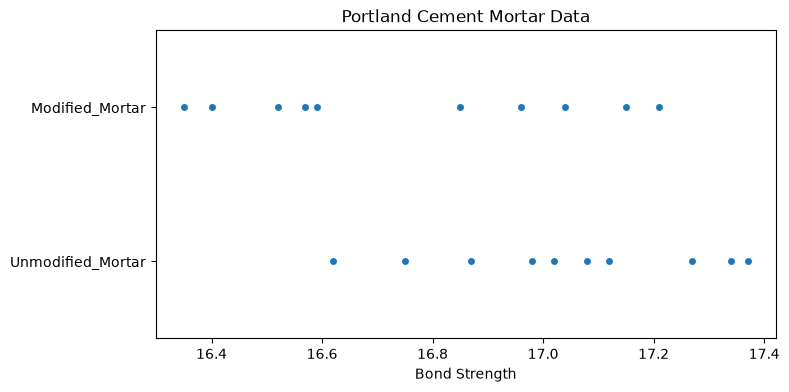

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.stripplot(
    data=df_long,
    x="Bond_Strength",
    y="Mortar_Type",
    jitter=False
)

plt.xlabel("Bond Strength")
plt.ylabel("")
plt.title("Portland Cement Mortar Data")

plt.show()

Der Box Plot fasst die Verteilung jeder Gruppe zusammen.
    
Dargestellt werden:

- Median
- Quartile
- Streuung
- mögliche Ausreißer

Die Zentren der beiden Verteilungen liegen sichtbar auseinander, während die Streuungen ähnlich erscheinen.

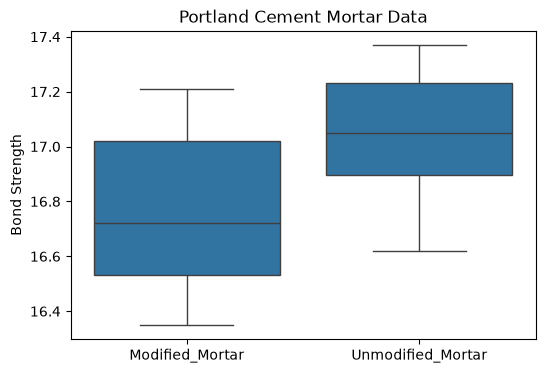

In [4]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="Mortar_Type",
    y="Bond_Strength"
)

plt.xlabel("")
plt.ylabel("Bond Strength")
plt.title("Portland Cement Mortar Data")

plt.show()

# Deskriptive Statistik

Als nächster Schritt werden die wichtigsten Kennzahlen berechnet.

Von besonderem Interesse sind:

- Stichprobenmittelwerte
- Standardabweichungen
- Varianzen

Diese Größen liefern erste Hinweise auf einen möglichen Unterschied zwischen den beiden Formulierungen und werden später für den Zweistichproben-ttt-Test benötigt.

In [5]:
df.describe()

,Modified_Mortar,Unmodified_Mortar
count,10.000000,10.000000
mean,16.764000,17.042000
std,0.316446,0.247916
min,16.350000,16.620000
25%,16.532500,16.897500
50%,16.720000,17.050000
75%,17.020000,17.232500
max,17.210000,17.370000


In [6]:
df.agg(["mean", "std", "var"])

,Modified_Mortar,Unmodified_Mortar
mean,16.764000,17.042000
std,0.316446,0.247916
var,0.100138,0.061462


# Zweistichproben-$t$-Test

Wir möchten untersuchen, ob sich die mittleren Zugverbundfestigkeiten der beiden Formulierungen unterscheiden.

Die Hypothesen lauten

$H_0:\mu_1=\mu_2$

$H_1:\mu_1\neq\mu_2$

Da die Stichproben ähnliche Varianzen aufweisen, verwenden wir den klassischen Zweistichproben-$t$-Test mit gepoolter Varianzschätzung

In [7]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    df["Modified_Mortar"],
    df["Unmodified_Mortar"],
    equal_var=True
)

print("Two-Sample t-Test")
print("-" * 30)
print(f"t-statistic        = {t_stat:.3f}")
print(f"degrees of freedom = {len(df)*2-2}")
print(f"p-value            = {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0 at α = 0.05")
else:
    print("\nConclusion: Do not reject H0 at α = 0.05")

Two-Sample t-Test
------------------------------
t-statistic        = -2.187
degrees of freedom = 18
p-value            = 0.0422

Conclusion: Reject H0 at α = 0.05


## Interpretation des Testergebnisses

Der Test liefert:

- Teststatistik $t$
- Freiheitsgrade
- $p$-Wert

Der beobachtete $p$-Wert liegt unter dem Signifikanzniveau von

$\alpha = 0.05$

Daher wird die Nullhypothese verworfen.

Die Daten liefern somit statistische Evidenz dafür, dass sich die mittlere Zugverbundfestigkeit der beiden Mörtelformulierungen unterscheidet.

In [8]:
import numpy as np
from scipy import stats

# Daten
y1 = df["Modified_Mortar"]
y2 = df["Unmodified_Mortar"]

# Kennzahlen
n1 = len(y1)
n2 = len(y2)

mean1 = y1.mean()
mean2 = y2.mean()

var1 = y1.var(ddof=1)
var2 = y2.var(ddof=1)

# Difference in means
mean_diff = mean1 - mean2

# pooled variance
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# standard error
se = sp * np.sqrt(1/n1 + 1/n2)

# degrees of freedom
dfree = n1 + n2 - 2

# critical t value
tcrit = stats.t.ppf(0.975, dfree)

# confidence interval
ci_lower = mean_diff - tcrit * se
ci_upper = mean_diff + tcrit * se

# t-test
t_stat, p_value = stats.ttest_ind(
    y1,
    y2,
    equal_var=True
)
print(f"Modified mortar mean      : {mean1:.2f}")
print(f"Unmodified mortar mean    : {mean2:.2f}")
print(f"Mean difference           = {mean_diff:.3f}")

print("-" * 30)


print("Two-Sample t-Test")
print("-" * 30)
print(f"t-statistic        = {t_stat:.3f}")
print(f"degrees of freedom = {len(df)*2-2}")
print(f"p-value            = {p_value:.4f}")
print(f"95% CI             = ({ci_lower:.3f}, {ci_upper:.3f})")

if p_value < 0.05:
    print("\nConclusion: Reject H0 at α = 0.05")
else:
    print("\nConclusion: Do not reject H0 at α = 0.05")

Modified mortar mean      : 16.76
Unmodified mortar mean    : 17.04
Mean difference           = -0.278
------------------------------
Two-Sample t-Test
------------------------------
t-statistic        = -2.187
degrees of freedom = 18
p-value            = 0.0422
95% CI             = (-0.545, -0.011)

Conclusion: Reject H0 at α = 0.05


## Konfidenzintervall für die Mittelwertsdifferenz
Neben dem Hypothesentest ist das Konfidenzintervall besonders hilfreich, da es die Größe des Effekts quantifiziert.

Für die Differenz

$\mu_1-\mu_2$

ergibt sich ein 95 %-Konfidenzintervall.

Da das Intervall den Wert

$0$

nicht enthält, bestätigt es das Ergebnis des Hypothesentests.

Darüber hinaus liefert das Intervall einen plausiblen Bereich für die wahre Differenz der mittleren Zugverbundfestigkeiten.

# Überprüfung der Annahmen

Der Zweistichproben-$t$-Test setzt voraus:

- Unabhängigkeit der Beobachtungen
- Normalverteilung innerhalb der Gruppen
- Gleiche Varianzen (für den gepoolten Test)

Die erste Annahme muss durch die Versuchsdurchführung begründet werden.

Die beiden weiteren Annahmen können grafisch überprüft werden.

## Normal Probability Plot

Ein Normal Probability Plot (Q-Q-Plot) vergleicht die beobachteten Daten mit den Quantilen einer Normalverteilung.

Liegen die Punkte ungefähr auf einer Geraden, spricht dies für die Annahme einer Normalverteilung.

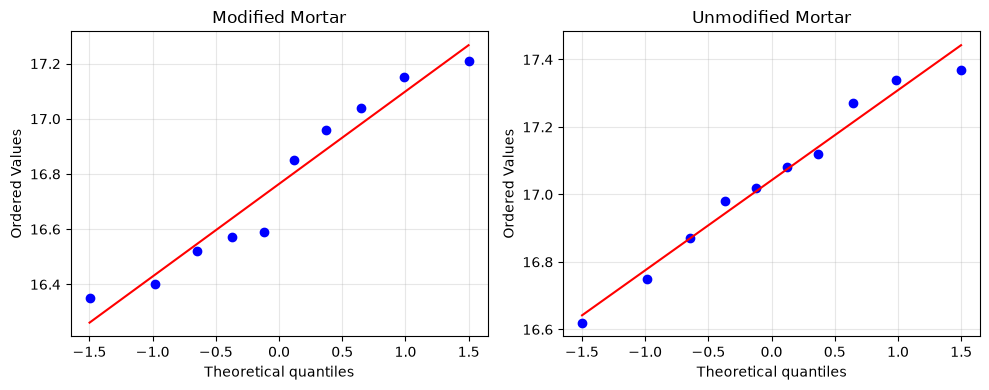

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, column in zip(
    axes,
    ["Modified_Mortar", "Unmodified_Mortar"]
):
    stats.probplot(
        df[column],
        dist="norm",
        plot=ax
    )

    ax.set_title(column.replace("_", " "))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

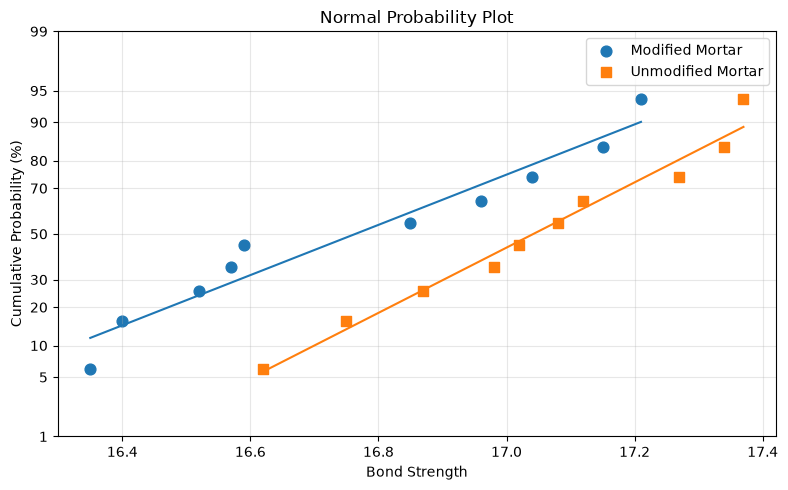

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))

for column, marker in [
    ("Modified_Mortar", "o"),
    ("Unmodified_Mortar", "s")
]:

    # sortierte Beobachtungen
    x = np.sort(df[column].values)
    n = len(x)

    # Blom plotting positions
    p = (np.arange(1, n + 1) - 0.375) / (n + 0.25)

    # Wahrscheinlichkeit -> Normal-Quantile
    z = stats.norm.ppf(p)

    ax.scatter(
        x,
        z,
        marker=marker,
        s=60,
        label=column.replace("_", " ")
    )

    # Regressionsgerade
    slope, intercept = np.polyfit(x, z, 1)

    xx = np.linspace(x.min(), x.max(), 100)

    ax.plot(
        xx,
        slope * xx + intercept,
        linewidth=1.5
    )

# Wahrscheinlichkeitsskala
prob_ticks = np.array([
    0.01, 0.05, 0.10,
    0.20, 0.30, 0.50,
    0.70, 0.80, 0.90,
    0.95, 0.99
])

ax.set_yticks(stats.norm.ppf(prob_ticks))
ax.set_yticklabels([f"{100*p:.0f}" for p in prob_ticks])

ax.set_xlabel("Bond Strength")
ax.set_ylabel("Cumulative Probability (%)")
ax.set_title("Normal Probability Plot")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

#plt.savefig("normal_probability_plot.pdf",bbox_inches="tight")
plt.show()


## Interpretation der Normal Probability Plots

- Punkte auf einer annähernden Geraden sprechen für Normalverteilung.
- Die Daten beider Rezepturen liegen ungefähr auf Geraden.
- Die Normalitätsannahme erscheint daher plausibel.
- Ähnliche Steigungen der Geraden deuten auf ähnliche Varianzen hin.
- Der gepoolte Zweistichproben-t-Test erscheint somit angemessen.
